# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [4]:
import pandas as pd

Load our cleaned DataFrames

In [3]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1DMzxq0adC39OVaijec1aJIGiLuV6YvDY/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path, parse_dates=[1])

# orderlines_cl.csv
url = "https://drive.google.com/file/d/17aZosef15cxGQ7bBmbhXKpu8wsITnDJ2/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path,parse_dates=[6])

# products_cl.csv
url = "https://drive.google.com/file/d/1crLwyUJvGMDX6kO40hVjLfvgNA4q12Qd/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [5]:
orders_quality = orders_cl.copy()
orderlines_quality = orderlines_cl.copy()
products_quality = products_cl.copy()

Let's create a copy of our DataFrames, to make sure any of our changes won't affect the original DataFrame. We'll also change the DataFrames from _cl to _qu, so we can differentiate between the data that has been cleaned, and that which has been quality controlled.

In [6]:
orderlines_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216250 entries, 0 to 216249
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_id        216250 non-null  int64         
 3   product_quantity  216250 non-null  int64         
 4   sku               216250 non-null  object        
 5   unit_price        216250 non-null  float64       
 6   date              216250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 11.5+ MB


## 1.&nbsp; Define Pandas display format

In [7]:
# your code here

pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 2.&nbsp; Exclude unwanted orders

In [8]:
# your code here
# orders –> Keep only orders with the states that you want to work with.

orders_quality.head() # just check the state column

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled


In [9]:
# just count the values by 'state'
orders_quality.state.value_counts()

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14374
Cancelled,7233


In [10]:
# For this task, we only need "completed" orders, so let's filter our Dataframe.
orders_quality = orders_quality.loc[orders_quality.state == "Completed",:]
orders_quality

,order_id,created_date,total_paid,state
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
5,245275,2017-06-28 11:35:37,149.00,Completed
6,245595,2017-01-21 12:52:47,112.97,Completed
...,...,...,...,...
226544,527042,2018-03-14 11:47:50,18.98,Completed
226572,527070,2018-03-14 11:50:48,24.97,Completed
226576,527074,2018-03-14 11:51:42,24.97,Completed
226598,527096,2018-03-14 11:58:40,34.96,Completed


In [11]:
# orderlines –> Keep only orders present in orders.
orders_quality.order_id.nunique()

46605

In [13]:
orderlines_quality.id_order.nunique()

170213

What a huge difference! We want to make sure that every **order_id** in **orders** also exists in **orderlines** and vice versa.

Hence we'll perform an inner merge on the two tables using the **order_id & id_order**. This will then keep only the '**order_id**'s that are present in both tables, which will then help us filter our '**_quality**' DataFrames once again.

In [14]:
orders_orderlines_merged = orders_quality.merge(orderlines_quality, how ="inner",left_on="order_id", right_on ="id_order")
orders_orderlines_merged

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,date
0,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,0,1,LAC0212,129.16,2017-11-06 12:47:20
1,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,0,1,PAR0074,10.77,2017-12-31 17:26:40
2,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,0,1,OWC0074,77.99,2017-02-15 17:07:44
3,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,0,1,TAD0007,149.00,2017-06-28 11:12:30
4,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,0,2,PAC1561,52.99,2017-01-21 12:49:00
...,...,...,...,...,...,...,...,...,...,...,...
56709,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38
56710,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01
56711,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36
56712,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35


In [15]:
# order_ids that are in both tables
order_ids = orders_orderlines_merged["order_id"].unique()

In [16]:
order_ids

array([241423, 242832, 243330, ..., 527074, 527096, 527112])

In [17]:
# keep those ids in orders
orders_quality = orders_quality.loc[orders_quality["order_id"].isin(order_ids), :]

# keep those ids in orderlines
orderlines_quality = orderlines_quality.loc[orderlines_quality["id_order"].isin(order_ids), :]

In [18]:
orders_quality.shape

(43064, 4)

Let's have a quick check to make sure we're filtering both DataFrames the same. They should both contain the same number of unique **order_id's**.

In [19]:
orders_quality["order_id"].nunique(),orderlines_quality["id_order"].nunique()

(43064, 43064)

In [20]:
#(orders_quality["order_id"].sort_values().tolist() == orderlines_quality["id_order"].sort_values().unique()).sum()

## 3.&nbsp; Exclude orders with unknown products


Let's start by investigating **orderlines** and **products**. We want to make sure that every product in **orderlines** has a matching entry in **products**. All orders with a missing product need to be removed from both **orderlines** and **orders**.

A left-join can help us here:

Joining **orderlines** left on **products** will keep all orderlines, and add the information of **products** on the matching skus. If an sku has been sold in **orderlines**, but the sku does not have an entry in **products** then the product_name will be empty.

In [21]:
# your code here
orderlines_products = orderlines_quality.merge(products_quality, how="left", on= "sku")[["id_order","sku","name"]]
orderlines_products

,id_order,sku,name
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD...
1,299546,IOT0014,iOttie Easy View 2 Car Black Support
2,295347,APP0700,Apple 85W MagSafe 2 charger MacBook Pro screen...
3,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200
4,299561,PEB0015,Pebble Smartwatch Time Steel Black
...,...,...,...
56709,525664,TUC0207,Tucano Elements Second Skin Macbook Sleeve 12 ...
56710,527070,APP0698,Apple Lightning Cable Connector to USB 1m Whit...
56711,527074,APP0698,Apple Lightning Cable Connector to USB 1m Whit...
56712,527096,APP0698,Apple Lightning Cable Connector to USB 1m Whit...


In [22]:
orderlines_products["name"].isna().value_counts()

,count
name,
False,55320
True,1394


Looks like the vast majority of products are known.

We can't simply delete the rows containing unknown products. We need to remove the entirety of any order that contains an unknown product to keep a consistent and coherent dataset.

In [23]:
orders_to_delete = orderlines_products.loc[orderlines_products["name"].isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526106, 526122, 526363])

 Keep only orders in orders and orderlines, that are not in this list of corrupted orders.

In [24]:
orders_quality = orders_quality.loc[~orders_quality["order_id"].isin(orders_to_delete),:]

In [25]:
orderlines_quality = orderlines_quality.loc[~orderlines_quality["id_order"].isin(orders_to_delete),:]

Let's have a quick check to make sure we're filtering both DataFrames the same. They should both contain the same number of unique **order_id's**.

In [26]:
orders_quality["order_id"].nunique(), orderlines_quality["id_order"].nunique()

(41701, 41701)

## 4.&nbsp; Explore the revenue from different tables

In a consistent and coherent dataset the value of an order should roughly match the sum of all items bought on that order. Let's investigate...

In [27]:
orderlines_qu_copy = orderlines_quality.copy()

In [28]:
orders_qu_copy = orders_quality.copy()

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [29]:
# your code here
orderlines_qu_copy["unit_price_total"] = orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]

In [30]:
orderlines_qu_copy.tail(10)

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
215873,1649440,527035,0,1,APP0498,23.00,2018-03-14 11:41:55,23.00
215874,1649441,527034,0,1,APP0927,13.99,2018-03-14 11:42:01,13.99
215876,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38,13.99
215877,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,9.99
215886,1649468,525664,0,1,TUC0336,7.93,2018-03-14 11:43:59,7.93
215889,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
215906,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
215911,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
215932,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97
215949,1649593,527112,0,1,APP0698,9.99,2018-03-14 11:58:13,9.99


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [31]:
# your code here
orderlines_order_ids = orderlines_qu_copy.groupby("id_order",as_index=False)["unit_price_total"].sum()

# as_index=False changes the return so that the groupedby column remains a column (not the index)

In [32]:
orderlines_order_ids

,id_order,unit_price_total
0,241423,129.16
1,242832,10.77
2,243330,77.99
3,245275,149.00
4,245595,105.98
...,...,...
41696,527042,13.99
41697,527070,19.98
41698,527074,19.98
41699,527096,29.97


### What is the average difference between `total_paid` and `unit_price_total`?

In [33]:
#Let's merge our grouped orderlines table with the orders table, so we can calculate the differences in prices.
diff_df = orders_qu_copy.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")


In [34]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
6,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
7,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
8,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99
9,251302,2017-05-10 12:27:33,140.99,Completed,251302,140.99,0.00


In [35]:
#Now that we know the difference for each order, we can compute the average.
diff_df.difference.mean().round(2)

np.float64(4.47)

### What is the distribution of these differences?

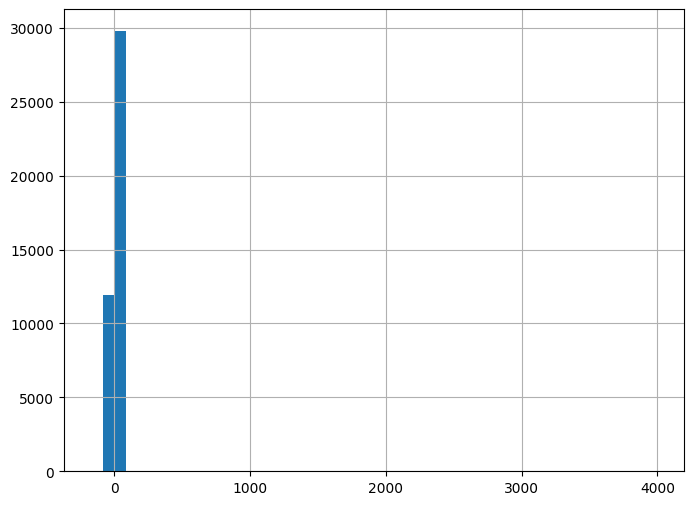

In [36]:
# your code here
diff_df["difference"].hist(bins= 50, figsize=(8,6));

Looking at the spread of the data above, some of the difference must be due to corruption. Let's use .describe() to investigate the distribution further.

In [37]:
diff_df["difference"].describe()

,difference
count,41701.00
mean,4.47
std,26.05
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


We can see from the our quartiles (0.00, 4.99, 6.99) that most of our data fits an expected pattern - free, 4.99, and 6.99 all seem like reasonable prices to assume as postage. However, look at the min and the max values, -165.00 and 3984.99, this can only occur due to corrupted data.

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

What reasons have you come up with to explain the difference?

### If there are differences that you can’t explain: what should you do with these orders?
There's a rule of thumb, that anything:

 * lower than the 25% quartile - (1.5 x interquartile range), or
 * higher than the 75% quartile + (1.5 x interquartile range)




is an outlier. Let's use this rule to try and exclude any corrupted data.

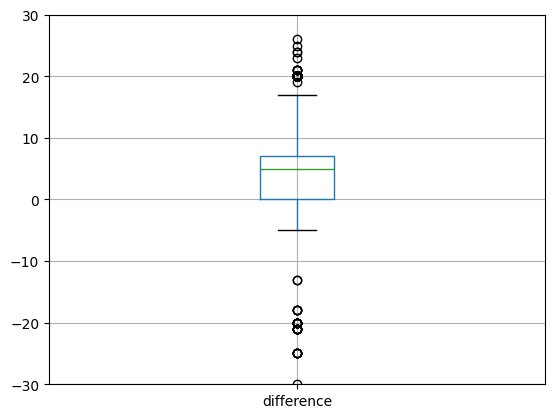

In [38]:
# We know this rule from the boxplot
import matplotlib.pyplot as plt

ax = diff_df.boxplot("difference");
ax.set_ylim(-30, +30)
plt.show()

In [39]:
# calculate the quartiles
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)

Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [40]:
# calculate the interquartile range
IQR = Q3-Q1
IQR

np.float64(6.989999999999981)

In [41]:
# lower boundary
Q1 - 1.5*IQR

np.float64(-10.484999999999971)

In [42]:
# upper boundary
Q3 + 1.5*IQR

np.float64(17.47499999999995)

In [43]:
# filter the DataFrame to include only "non-outliers"
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (diff_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]

In [44]:
diff_no_outliers_df

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
...,...,...,...,...,...,...,...
41696,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99,4.99
41697,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98,4.99
41698,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98,4.99
41699,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97,4.99


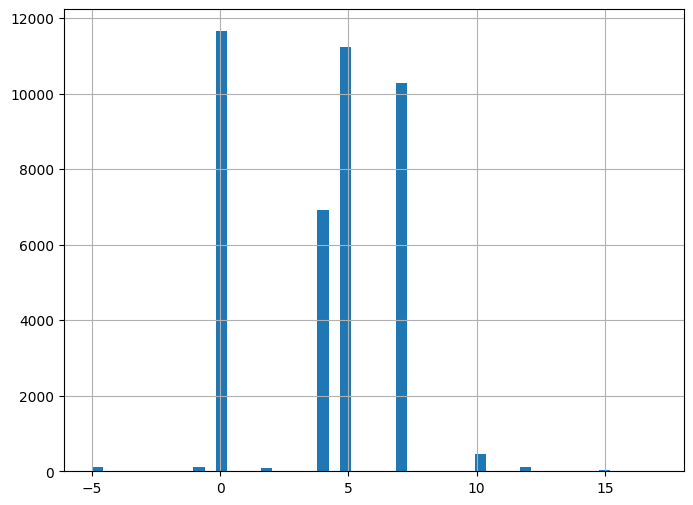

In [45]:
#Let's look at the distribution again to see the effect of removing the outliers.
diff_no_outliers_df["difference"].hist(bins= 50, figsize=(8,6));

<Axes: >

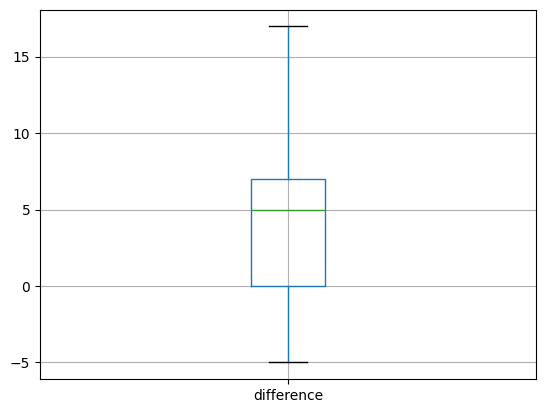

In [46]:
diff_no_outliers_df.boxplot("difference")

This looks much more like what we would expect: a small difference, but nothing extreme.

Now we need to remove these orders with extreme differences from our **orders_lines_merged** DataFrame.

In [47]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [48]:
orders_quality = orders_quality.loc[orders_quality["order_id"].isin(normal_diff_list), :]
orderlines_quality = orderlines_quality.loc[orderlines_quality["id_order"].isin(normal_diff_list), :]

In [49]:
orders_quality["order_id"].nunique(), orderlines_quality["id_order"].nunique()

(40985, 40985)

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

Do not forget to download your quality controlled DataFrames

In [50]:
from google.colab import files

orders_quality.to_csv("orders_quality.csv", index=False)
files.download("orders_quality.csv")

orderlines_quality.to_csv("orderlines_quality.csv", index=False)
files.download("orderlines_quality.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>